In [368]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hellbuoy/car-price-prediction/CarPrice_Assignment.csv
/kaggle/input/datasets/hellbuoy/car-price-prediction/Data Dictionary - carprices.xlsx


In [369]:
df = pd.read_csv('/kaggle/input/datasets/hellbuoy/car-price-prediction/CarPrice_Assignment.csv')
pd.set_option('display.max_columns', None)
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [370]:
df = df.drop(columns=['car_ID','symboling','CarName'])
df.head()

,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginetype,cylindernumber,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [371]:
df.isnull().sum()

fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [372]:
for i in df:
    if(type(df[i][0]) == str):
        print(df[i].unique(),i)

['gas' 'diesel'] fueltype
['std' 'turbo'] aspiration
['two' 'four'] doornumber
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop'] carbody
['rwd' 'fwd' '4wd'] drivewheel
['front' 'rear'] enginelocation
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv'] enginetype
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight'] cylindernumber
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi'] fuelsystem


In [373]:
# df['fueltype'] = df['fueltype'].map({'gas':0,'diesel':1})

In [374]:
for i in df:
    if(type(df[i][0]) == str):
        unique_values = df[i].unique()
        if(len(unique_values)==2):
            df[i] = df[i].map({unique_values[0]:0,unique_values[1]:1})
        else:
            df = pd.get_dummies(df, columns=[i], prefix=i, dtype=int)

In [375]:
df.head()

,fueltype,aspiration,doornumber,enginelocation,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,carbody_convertible,carbody_hardtop,carbody_hatchback,carbody_sedan,carbody_wagon,drivewheel_4wd,drivewheel_fwd,drivewheel_rwd,enginetype_dohc,enginetype_dohcv,enginetype_l,enginetype_ohc,enginetype_ohcf,enginetype_ohcv,enginetype_rotor,cylindernumber_eight,cylindernumber_five,cylindernumber_four,cylindernumber_six,cylindernumber_three,cylindernumber_twelve,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,0,0,0,0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,13495.0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0,0,0,0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27,16500.0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26,16500.0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,0,0,1,0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30,13950.0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0,0,1,0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22,17450.0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0


In [376]:
df.dtypes

fueltype                   int64
aspiration                 int64
doornumber                 int64
enginelocation             int64
wheelbase                float64
carlength                float64
carwidth                 float64
carheight                float64
curbweight                 int64
enginesize                 int64
boreratio                float64
stroke                   float64
compressionratio         float64
horsepower                 int64
peakrpm                    int64
citympg                    int64
highwaympg                 int64
price                    float64
carbody_convertible        int64
carbody_hardtop            int64
carbody_hatchback          int64
carbody_sedan              int64
carbody_wagon              int64
drivewheel_4wd             int64
drivewheel_fwd             int64
drivewheel_rwd             int64
enginetype_dohc            int64
enginetype_dohcv           int64
enginetype_l               int64
enginetype_ohc             int64
enginetype

In [377]:
X, y = df.drop(columns=['price']), df['price']

In [378]:
X_data = np.array(X)
y_data = np.array(y).reshape(-1,1)

print(X_data)
print(y_data[:2])

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 1. ... 1. 0. 0.]
 [1. 1. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 1. 0. 0.]]
[[13495.]
 [16500.]]


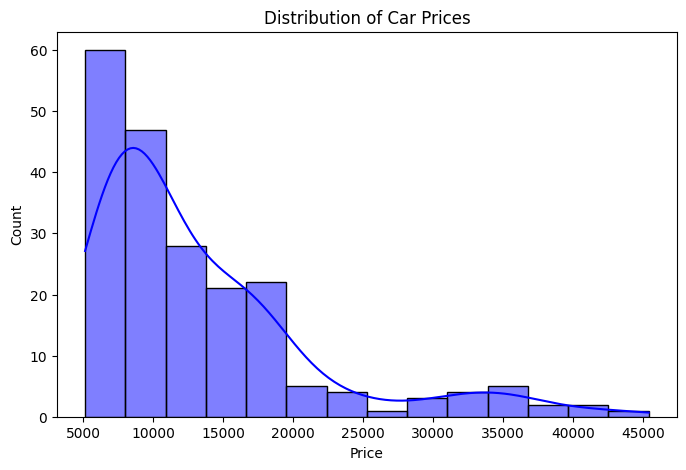

In [379]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()


In [380]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import ElasticNet

X_train,X_test,y_train,y_test = train_test_split(X_data,y_data,test_size = 0.2 , random_state= 42)


#-------------------------------------------------------------

poly = PolynomialFeatures(degree = 2, include_bias = False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

X_elastic_scaling = StandardScaler()

X_train_scaled = X_elastic_scaling.fit_transform(X_train_poly)

model_fs = ElasticNet(alpha = 0.1,l1_ratio = 0.5, max_iter=100000,tol=1e-3)
model_fs.fit(X_train_scaled,y_train.ravel())
fs_imp = model_fs.coef_ != 0 

X_train = X_train_poly[:,fs_imp]
X_test = X_test_poly[:,fs_imp]

#-------------------------------------------------------------------

X_scaler = StandardScaler()
y_scaler = StandardScaler()



X_train_scaler = X_scaler.fit_transform(X_train)
X_test_scaler = X_scaler.transform(X_test)
# y_train_scaler = y_scaler.fit_transform(y_train)
# y_test_scaler = y_scaler.transform(y_test)



y_train_scaler = y_scaler.fit_transform(y_train.reshape(-1, 1))
y_test_scaler = y_scaler.transform(y_test.reshape(-1, 1))

print(X_train_scaler[:2])
print(y_train_scaler[:2])


[[-0.46348119  0.91798509 -0.13650473 ... -0.95235327 -0.19487094
  -0.07832604]
 [-0.46348119  0.91798509 -0.13650473 ...  1.05003052 -0.19487094
  -0.07832604]]
[[0.66306891]
 [0.30515622]]


In [381]:
import torch

X_train_scaler_torch = torch.tensor(X_train_scaler, dtype = torch.float32)
X_test_scaler_torch = torch.tensor(X_test_scaler, dtype = torch.float32)
y_train_scaler_torch = torch.tensor(y_train_scaler, dtype = torch.float32)
y_test_scaler_torch = torch.tensor(y_test_scaler, dtype = torch.float32)

print(X_train_scaler_torch[:2])
print(y_train_scaler_torch[:2])

tensor([[-0.4635,  0.9180, -0.1365,  ..., -0.9524, -0.1949, -0.0783],
        [-0.4635,  0.9180, -0.1365,  ...,  1.0500, -0.1949, -0.0783]])
tensor([[0.6631],
        [0.3052]])


In [382]:
input_size1 = X_data.shape[1]
print(input_size1)

input_size2 = X_train_scaler_torch.shape[1]
print(input_size2)

47
754


In [383]:
import torch.nn as nn
import torch.optim as optim 

# input_size = X_data.shape[1]

input_size = X_train_scaler_torch.shape[1]

model = nn.Sequential(
    nn.Linear(input_size,64),
    nn.ReLU(),
    nn.Linear(64,32),
    nn.ReLU(),
    nn.Linear(32,1),
)

loss_fun = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr=0.01)

epochs = 1000
for i in range(epochs):
    model.train()
    output = model(X_train_scaler_torch)
    loss = loss_fun(output,y_train_scaler_torch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    if i % 100 == 0:
        print(f"loss {loss.item()}")


from sklearn.metrics import r2_score,mean_absolute_error
model.eval()
with torch.no_grad():
    output = model(X_test_scaler_torch)
    r2 = r2_score(y_test_scaler_torch, output)
    mae = mean_absolute_error(y_test_scaler_torch,output)
    print(f"r2_score {r2*100}")
    print(f"mean_absolute_error {mae}")

loss 1.0515748262405396
loss 0.05035137012600899
loss 0.03356950357556343
loss 0.026013901457190514
loss 0.02155277132987976
loss 0.01857498288154602
loss 0.016490429639816284
loss 0.014908673241734505
loss 0.013660785742104053
loss 0.012802466750144958
r2_score 94.40326229335014
mean_absolute_error 0.1911465189442402


In [384]:
# Convert PyTorch evaluation variables to NumPy arrays
predictions_scaled_np = output.numpy()
y_test_scaled_np = y_test_scaler_torch.numpy()

# Inverse transform back to the original dollar currency scale
predictions_dollars = y_scaler.inverse_transform(predictions_scaled_np)
y_test_dollars = y_scaler.inverse_transform(y_test_scaled_np)

# Compute real-world monetary error
final_dollar_mae = mean_absolute_error(y_test_dollars, predictions_dollars)
print(f"🎯 Verified Real-World Error: On average, the model is off by only ${final_dollar_mae:.2f}")


🎯 Verified Real-World Error: On average, the model is off by only $1476.14
